# Part B -- Practical (Python Programming)

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('employee_performance.csv')
df.head()

,Employee_ID,Department,Age,Salary,Projects_Completed,Working_Hours,Performance_Score,Promotion_Status
0,EMP1001,Operations,28,28278,9,37,54,No
1,EMP1002,HR,55,36395,19,43,42,Yes
2,EMP1003,IT,35,91237,20,30,75,Yes
3,EMP1004,Operations,55,79987,8,44,77,Yes
4,EMP1005,HR,31,116506,14,40,57,No


## Step 1: Central Tendency & Dispersion

### - Find mean,median and mode of salary

In [4]:
mean_salary = df['Salary'].mean()
median_salary = df['Salary'].median()
mode_salary = df['Salary'].mode()[0]

print(f"Mean Salary: {mean_salary}")
print(f"Median Salary: {median_salary}")
print(f"Mode Salary: {mode_salary}")

Mean Salary: 72753.76
Median Salary: 73313.5
Mode Salary: 25207


### - Calculate variance and standard deviation of Projects_Completed.

In [5]:
variance_projects = df['Projects_Completed'].var()
std_dev_projects = df['Projects_Completed'].std()

print(f"Variance of Projects Completed: {variance_projects}")
print(f"Standard Deviation of Projects Completed: {std_dev_projects}")

Variance of Projects Completed: 33.10947111777944
Standard Deviation of Projects Completed: 5.754082995385055


## Step 2: Probabiity & Events

### - Find the probability of employees getting promoted.

In [25]:
promoted_employees = df[df['Promotion_Status'] == 'Yes']
probability_promotion = len(promoted_employees) / len(df)
print(f"Probability of Promotion: {probability_promotion}")

Probability of Promotion: 0.40475


### - Create a contingency table between Promotion_Status and Department.

In [11]:
contingency_table = pd.crosstab(df['Promotion_Status'], df['Department'])
print("Contingency Table between Promotion_Status and Department:")
display(contingency_table)

Contingency Table between Promotion_Status and Department:


Department,Finance,HR,IT,Marketing,Operations,Sales
Promotion_Status,,,,,,
No,397,424,397,378,395,390
Yes,289,289,250,265,255,271


### - Compute conditional probability: P(Promotion | Performance_Score > 80).

In [24]:
performance_employees = df[df['Performance_Score'] > 80]
conditional_probability = len(performance_employees[performance_employees['Promotion_Status'] == 'Yes']) / len(performance_employees)
print(f"Conditional Probability of Promotion given Performance_Score > 80: {conditional_probability}")

Conditional Probability of Promotion given Performance_Score > 80: 0.7940941739824421


## Step 3: Distributions & Visualization

### - Plot a Histogram of Performance_Score with a Gaussian curve.

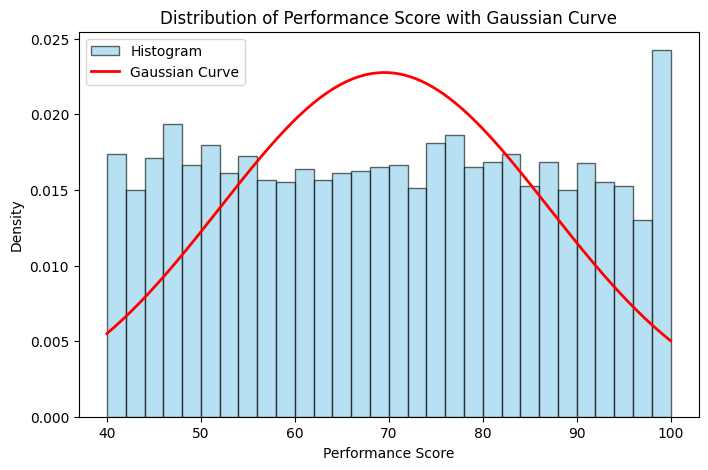

In [16]:
import matplotlib.pyplot as plt

scores = df['Performance_Score']
mu = scores.mean()
sigma = scores.std()

plt.figure(figsize=(8, 5))
plt.hist(scores, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Histogram')

x = np.linspace(scores.min(), scores.max(), 200)
gauss = 1 / (sigma * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
plt.plot(x, gauss, 'r-', linewidth=2, label='Gaussian Curve')

plt.xlabel('Performance Score')
plt.ylabel('Density')
plt.title('Distribution of Performance Score with Gaussian Curve')
plt.legend()
plt.show()

### - Check Skewness and Kurtosis for Salary.

In [18]:
skewness = df['Salary'].skew()
kurtosis = df['Salary'].kurtosis()

print(f"Skewness of Salary: {skewness}")
print(f"Kurtosis of Salary: {kurtosis}")

Skewness of Salary: -0.011032894325163054
Kurtosis of Salary: -1.1869236654229594


### - Draw a Q-Q Plot of Projects_Completed.

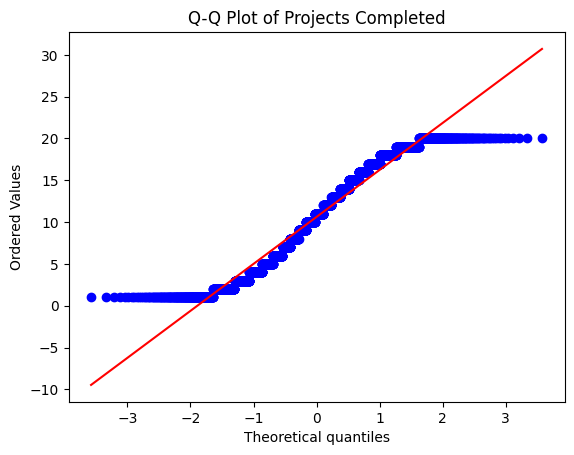

In [19]:
import scipy.stats as stats

stats.probplot(df['Projects_Completed'], dist="norm", plot=plt)
plt.title('Q-Q Plot of Projects Completed')
plt.show()

## Step 4: Linear Algrbra Application.

### Take the first 5 employees' [Projects_Completed, Working_Hours] as vectors.

### - Perform dot product between two employee vectors.

In [20]:
v1 = np.array([1, 2, 3])    
v2 = np.array([4, 5, 6])
dot_product = np.dot(v1, v2)
print(f"Dot Product of v1 and v2: {dot_product}")

Dot Product of v1 and v2: 32


### - Find Norm 1 & Norm 2 of an employee's work vector.

In [21]:
norm1 = np.linalg.norm(v1, ord=1)
norm2 = np.linalg.norm(v1, ord=2)
print(f"Norm 1 of v1: {norm1}")
print(f"Norm 2 of v1: {norm2}")

Norm 1 of v1: 6.0
Norm 2 of v1: 3.7416573867739413


### - Compute the angle between two employee's work vector.

In [23]:
angle = np.arccos(dot_product / (np.linalg.norm(v1) * np.linalg.norm(v2)))
print(f"Angle between v1 and v2 (in radians): {angle}")

Angle between v1 and v2 (in radians): 0.2257261285527342
